In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [4]:
df = pd.read_csv("student.csv")

df.head()


,StudyHours,Attendance,PreviousScore,Result
0,2,60,45,Fail
1,3,65,50,Fail
2,4,70,55,Fail
3,5,75,60,Pass
4,6,80,65,Pass


In [8]:
print("Shape:", df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistics:")
print(df.describe())

Shape: (10, 4)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   StudyHours     10 non-null     int64
 1   Attendance     10 non-null     int64
 2   PreviousScore  10 non-null     int64
 3   Result         10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes
None

Statistics:
       StudyHours  Attendance  PreviousScore     Result
count    10.00000   10.000000      10.000000  10.000000
mean      5.50000   76.800000      64.000000   0.600000
std       3.02765   15.711284      17.126977   0.516398
min       1.00000   50.000000      40.000000   0.000000
25%       3.25000   66.250000      51.250000   0.000000
50%       5.50000   77.500000      62.500000   1.000000
75%       7.75000   88.750000      77.500000   1.000000
max      10.00000   98.000000      90.000000   1.000000


In [9]:
print(df.isnull().sum())

StudyHours       0
Attendance       0
PreviousScore    0
Result           0
dtype: int64


In [10]:
encoder = LabelEncoder()

df["Result"] = encoder.fit_transform(df["Result"])

df.head()

,StudyHours,Attendance,PreviousScore,Result
0,2,60,45,0
1,3,65,50,0
2,4,70,55,0
3,5,75,60,1
4,6,80,65,1


In [11]:
X = df[["StudyHours", "Attendance", "PreviousScore"]]

y = df["Result"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (8, 3)
Testing Data: (2, 3)


In [13]:
model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [14]:
y_pred = model.predict(X_test)

print(y_pred)

[0 0]


In [16]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [17]:
new_student = [[7, 85, 70]]

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("Result: Pass")
else:
    print("Result: Fail")

Result: Pass


c:\Users\aipa_\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


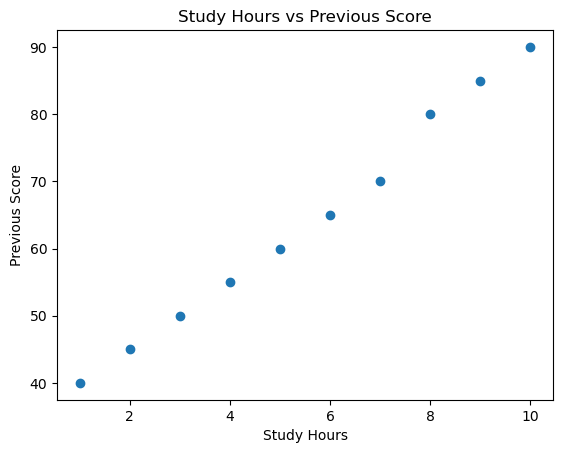

In [18]:
import matplotlib.pyplot as plt

plt.scatter(df["StudyHours"], df["PreviousScore"])
plt.xlabel("Study Hours")
plt.ylabel("Previous Score")
plt.title("Study Hours vs Previous Score")
plt.show()